### **About Dataset**
### Context
This dataset contains detailed information about residential properties available 
for rent in major Indian cities. It captures key features of rental listings, including
property type, location, size, amenities, and rental price. This data is suitable for 
analyzing rental market trends, predicting rental prices, and understanding the distribution
of residential properties across different urban areas in India.

### Content
The dataset comprises 7,691 records and 10 columns. Each row represents a unique rental listing.

### Columns:

house_type (String): A descriptive title of the listing, often including the configuration 
(e.g., "2 BHK Flat"), property type (Flat/House), project name, and location.

locality (String): The specific neighborhood or area within the city where the property is located 
    (e.g., "Goregaon East", "Whitefield").

city (String): The city where the property is situated. The dataset covers the following cities:

New Delhi

Bangalore

Pune

Mumbai

Nagpur


area (Float): The size of the property in square feet (sq. ft.).

Range: 2 sq. ft. to 70,000 sq. ft. (Note: The minimum value of 2 might indicate data entry errors or specific non-standard units).

beds (Integer): The number of bedrooms in the property.

Range: 1 to 10 bedrooms.

bathrooms (Integer): The number of bathrooms available.

Range: 0 to 10 bathrooms.

balconies (Integer): The number of balconies in the property.

Range: 0 to 10 balconies.

furnishing (String): The furnishing status of the property. Categories include:

Semi-Furnished

Unfurnished

Furnished

area_rate (Float): The calculated rental rate per square foot (likely rent / area).

rent (Float): The monthly rental price in Indian Rupees (INR).

Range: ₹1,000 to ₹2,700,000.

Mean Rent: ~₹54,795

Median Rent: ₹28,000

Inspiration

This dataset can be used for various data science and analysis projects, such as:

Rent Prediction: Build a regression model to predict the monthly rent based on features like city, area, and 
number of bedrooms.

Market Analysis: Analyze the rental price distribution across different cities and localities.

Feature Importance: Determine which factors (e.g., furnishing status, number of bathrooms)
have the most significant impact on rental prices.

Outlier Detection: Identify luxury properties or potential data entry errors based on extreme rent or area values.
### Acknowledgements
If this dataset was scraped or sourced from a specific real estate portal, you would typically acknowledge the source here. (Since the source is not specified in the file, you can leave this generic or omit it).

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\nagasri15\Downloads\data.csv')
df

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0
...,...,...,...,...,...,...,...,...,...,...
7686,"3 BHK Flat for Rent in Saket, New Delhi",Saket,New Delhi,1750.0,3,3,0,Furnished,27.0,47000.0
7687,"2 BHK Flat for Rent in Phase 7 JP Nagar, Banga...",Phase 7 JP Nagar,Bangalore,1050.0,2,2,2,Semi-Furnished,27.0,28000.0
7688,"2 BHK Flat for Rent in Malpani Vivanta, Balewa...",Balewadi,Pune,734.0,2,2,2,Unfurnished,48.0,35000.0
7689,"1 BHK Flat for Rent in Shalimar bagh, New Delhi",Shalimar bagh,New Delhi,400.0,1,1,0,Semi-Furnished,38.0,15000.0


In [3]:
df['furnishing'].value_counts()

furnishing
Semi-Furnished    3428
Unfurnished       2662
Furnished         1601
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_type  7691 non-null   object 
 1   locality    7691 non-null   object 
 2   city        7691 non-null   object 
 3   area        7691 non-null   float64
 4   beds        7691 non-null   int64  
 5   bathrooms   7691 non-null   int64  
 6   balconies   7691 non-null   int64  
 7   furnishing  7691 non-null   object 
 8   area_rate   7691 non-null   float64
 9   rent        7691 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 601.0+ KB


In [5]:
df.shape

(7691, 10)

In [6]:
df.size

76910

In [7]:
df['beds'].value_counts()

beds
2     3046
3     2035
1     1947
4      541
5       99
10       8
6        6
8        5
7        4
Name: count, dtype: int64

In [8]:
df.isnull().sum()

house_type    0
locality      0
city          0
area          0
beds          0
bathrooms     0
balconies     0
furnishing    0
area_rate     0
rent          0
dtype: int64

In [9]:
df.drop('house_type', axis=1, inplace=True)
df

,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0
...,...,...,...,...,...,...,...,...,...
7686,Saket,New Delhi,1750.0,3,3,0,Furnished,27.0,47000.0
7687,Phase 7 JP Nagar,Bangalore,1050.0,2,2,2,Semi-Furnished,27.0,28000.0
7688,Balewadi,Pune,734.0,2,2,2,Unfurnished,48.0,35000.0
7689,Shalimar bagh,New Delhi,400.0,1,1,0,Semi-Furnished,38.0,15000.0


In [10]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df["locality"]=le.fit_transform(df["locality"])
df["city"]=le.fit_transform(df["city"])
df["furnishing"]=le.fit_transform(df["furnishing"])
df

,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,585,1,897.0,2,2,0,1,134.0,120000.0
1,1389,1,490.0,1,1,0,1,82.0,40000.0
2,1179,4,550.0,1,1,0,2,22.0,12000.0
3,670,2,1000.0,2,2,0,2,8.0,8000.0
4,1146,1,595.0,1,1,0,2,25.0,15000.0
...,...,...,...,...,...,...,...,...,...
7686,1512,3,1750.0,3,3,0,0,27.0,47000.0
7687,1369,0,1050.0,2,2,2,1,27.0,28000.0
7688,137,4,734.0,2,2,2,2,48.0,35000.0
7689,1650,3,400.0,1,1,0,1,38.0,15000.0


In [11]:
df.corr()

,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
locality,1.000000,0.094312,-0.011015,-0.018327,-0.024606,0.005253,0.016716,-0.027965,-0.015245
city,0.094312,1.000000,-0.125663,-0.131277,-0.163518,0.004278,0.093305,-0.145132,-0.171352
area,-0.011015,-0.125663,1.000000,0.516329,0.535668,0.296145,-0.090037,0.022209,0.433513
beds,-0.018327,-0.131277,0.516329,1.000000,0.850310,0.418587,-0.118684,0.111820,0.473695
bathrooms,-0.024606,-0.163518,0.535668,0.850310,1.000000,0.442145,-0.130125,0.160051,0.532681
balconies,0.005253,0.004278,0.296145,0.418587,0.442145,1.000000,-0.042480,-0.004592,0.179181
furnishing,0.016716,0.093305,-0.090037,-0.118684,-0.130125,-0.042480,1.000000,-0.086916,-0.124648
area_rate,-0.027965,-0.145132,0.022209,0.111820,0.160051,-0.004592,-0.086916,1.000000,0.507104
rent,-0.015245,-0.171352,0.433513,0.473695,0.532681,0.179181,-0.124648,0.507104,1.000000


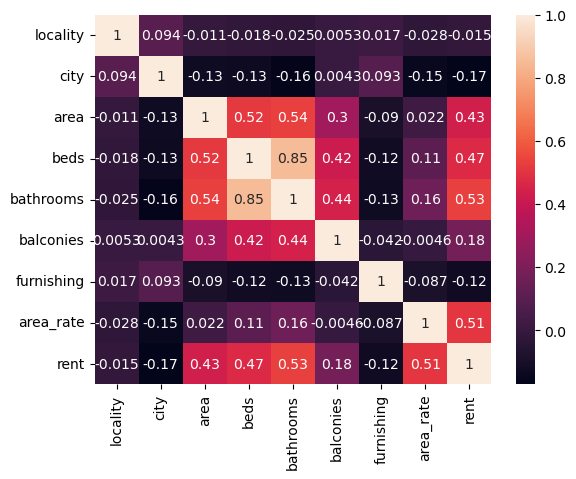

In [12]:
sns.heatmap(df.corr(), annot=True)
plt.show()

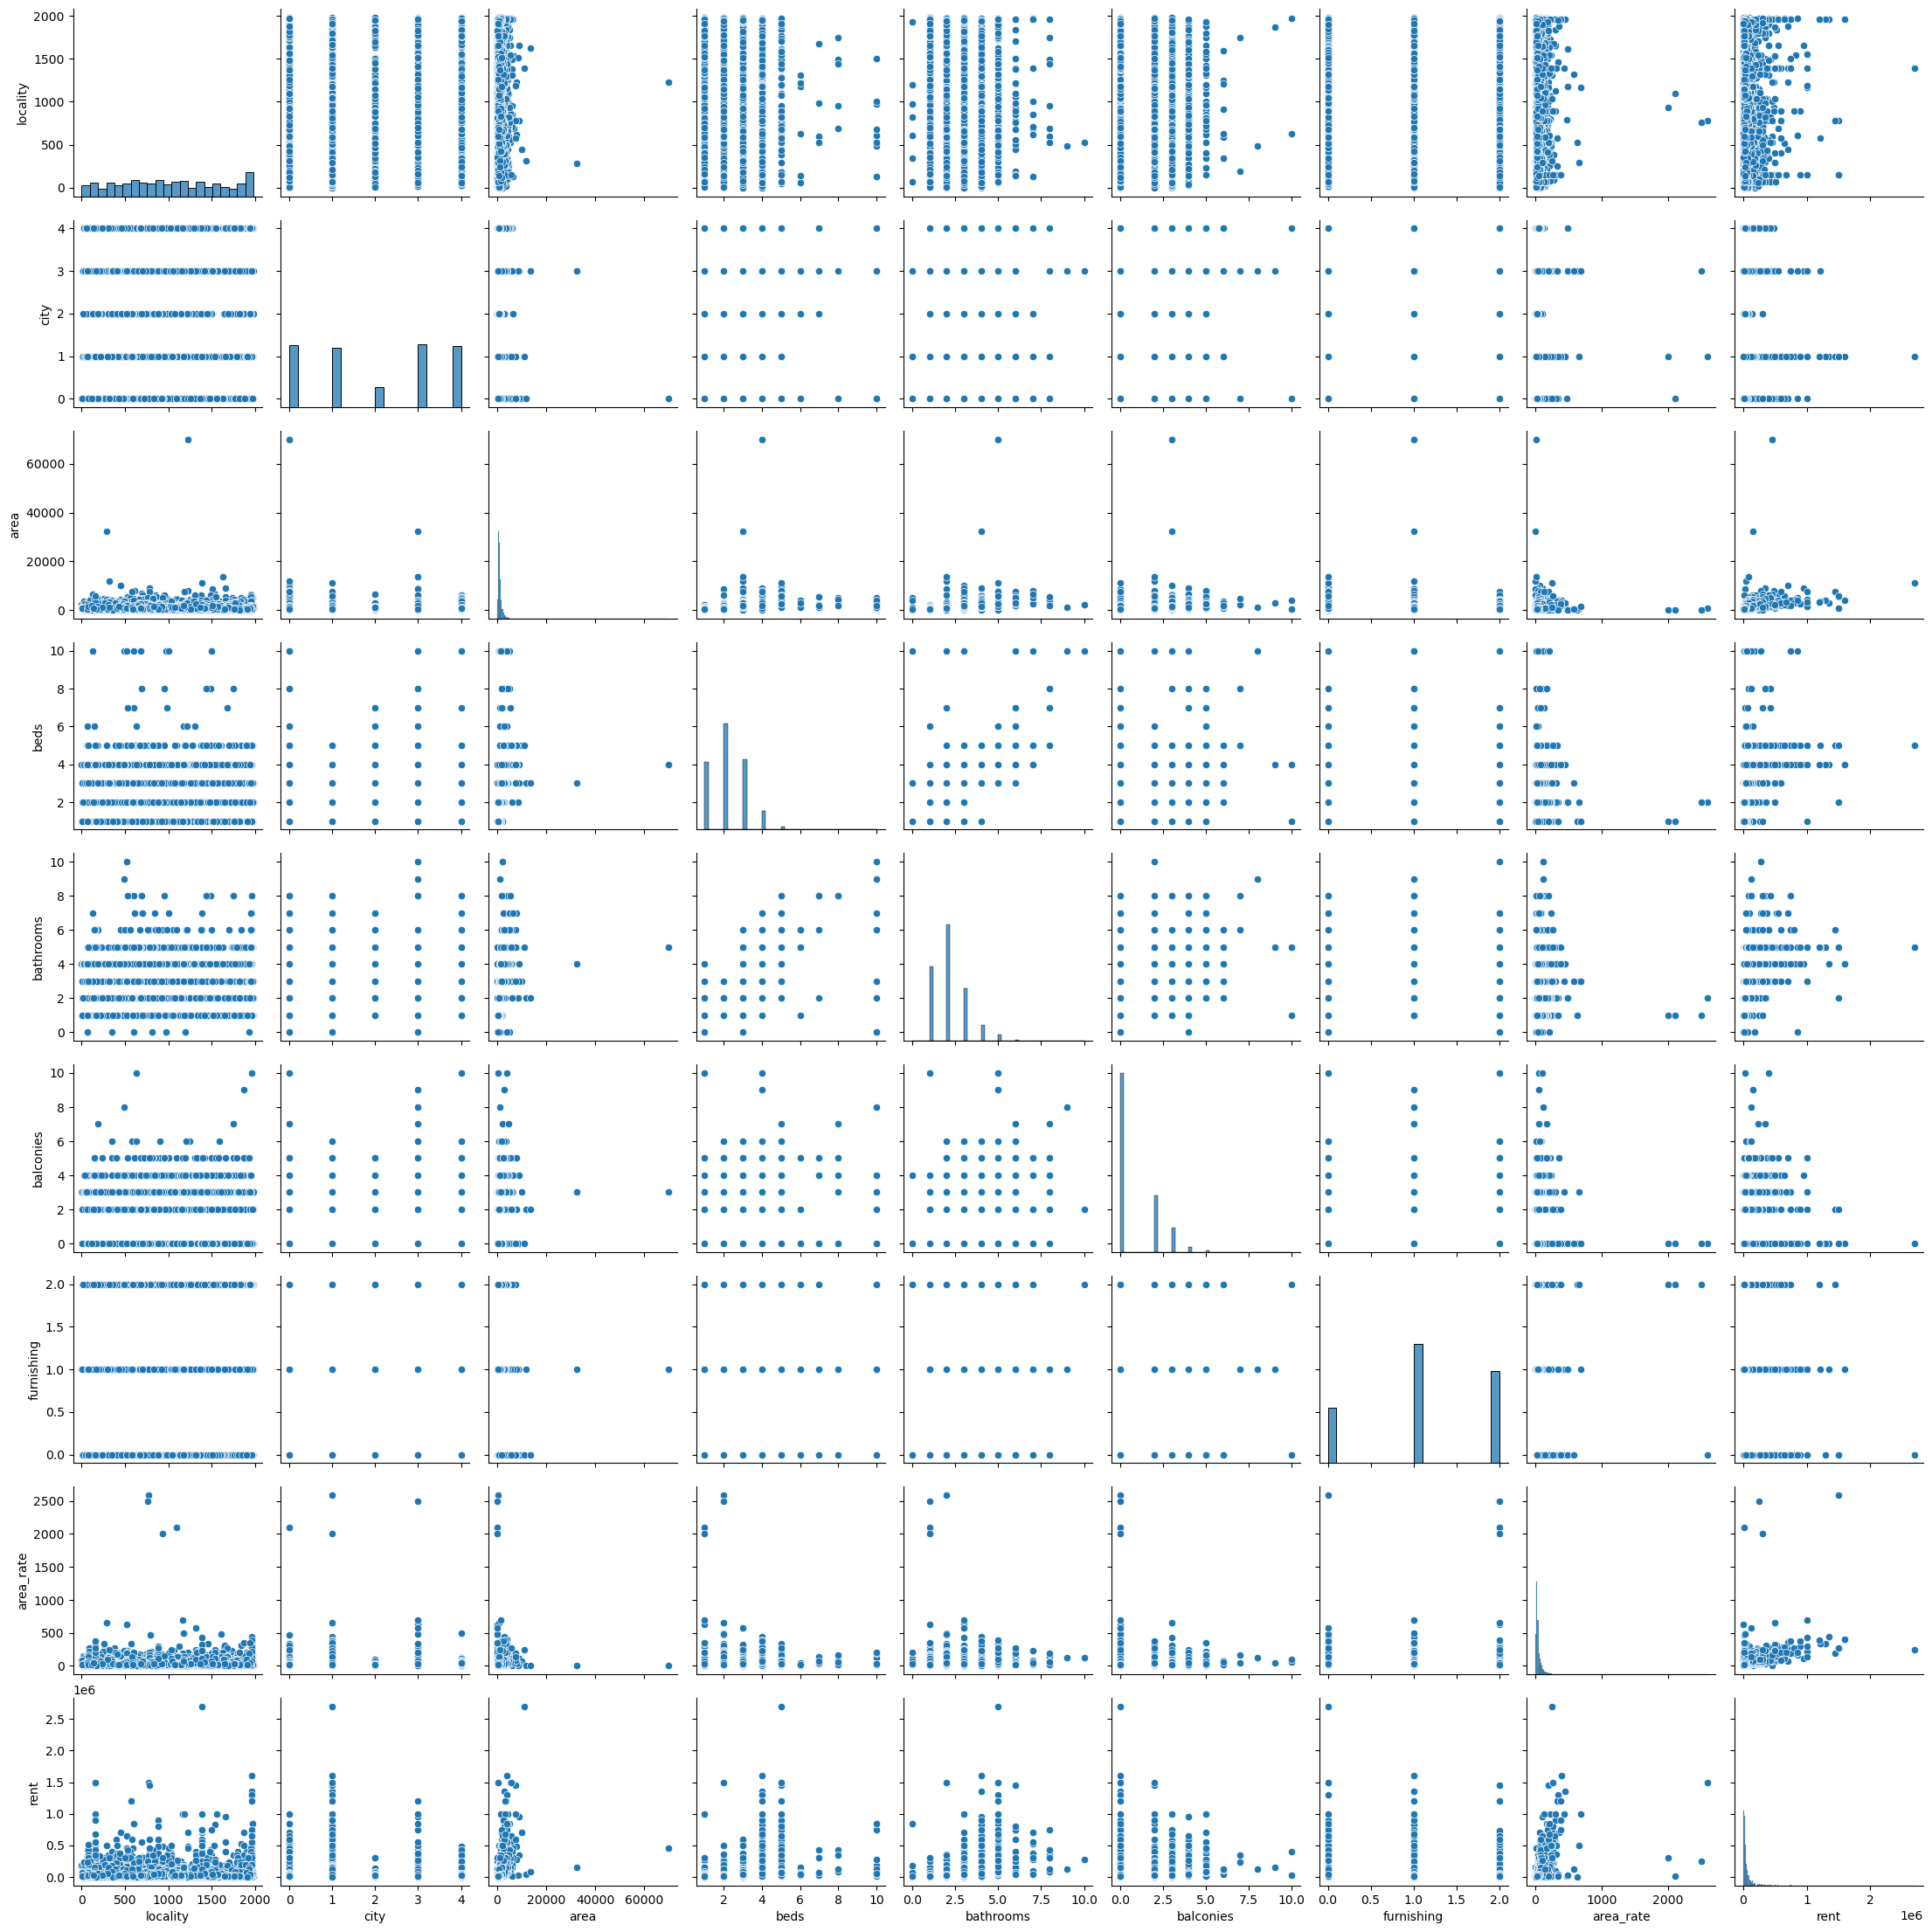

In [13]:
sns.pairplot(df)
plt.show()

In [14]:
x = df.drop(columns = 'rent')
y = df['rent']

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 45)

In [16]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_converter = PolynomialFeatures(degree = 2, include_bias = False)
x_train = pd.DataFrame(polynomial_converter.fit_transform(x_train))
x_test = pd.DataFrame(polynomial_converter.transform(x_test))

In [17]:
x_train.shape

(5383, 44)

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
model = LinearRegression()

In [20]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
model.intercept_

np.float64(-307.83784455554996)

In [22]:
model.coef_

array([-3.57298157e-01,  2.33952876e+02,  4.40468200e-01,  3.26327441e+02,
       -7.44161858e+02,  1.73401692e+02,  3.16835364e+02,  1.09141443e+01,
        2.74346578e-05,  2.99973451e-02, -6.91762751e-04, -1.17835868e-02,
        5.76523481e-01, -6.14797479e-02,  6.06828762e-02, -3.20356987e-03,
       -7.47611068e+01, -2.28359055e-01, -1.49596304e+01,  1.82822115e+02,
        1.03618170e+01, -3.58596945e+00, -7.19352121e-01,  1.78168761e-05,
        1.66032350e-01, -3.37812573e-01,  1.32755508e-01,  1.46150307e-01,
        1.00622406e+00, -6.71587078e+01,  1.76201064e+01, -1.04116520e+02,
        4.66120978e+01,  5.65175412e-01,  2.00683205e+02,  2.55652367e+01,
       -2.02890157e+02, -4.67433688e+00, -3.19448273e+01, -2.33414229e+01,
       -1.56801889e-01, -9.74419649e+01, -5.43154597e-01, -1.13030507e-03])

In [23]:
train_predictions=model.predict(x_train)

In [24]:
test_predictions=model.predict(x_test)

In [25]:
from sklearn.metrics import r2_score
print("R2 for test data: ",r2_score(y_test,test_predictions))
print("R2 for train data: ",r2_score(y_train,train_predictions))

R2 for test data:  0.9997272677712598
R2 for train data:  0.9994486325829611


In [26]:
model.score(x_test,y_test)

0.9997272677712598

In [27]:
model.score(x_train,y_train)

0.9994486325829611

In [28]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x_train,y_train,cv=2)
print(scores)
cv_score=scores.mean()
print('Cross Validation Score:',cv_score)

[0.99913035 0.96251907]
Cross Validation Score: 0.9808247129040648
